# Imports

In [1]:
import torch

import random

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm.notebook import tqdm

from copy import deepcopy
from sklearn.preprocessing import MinMaxScaler

### Set seed and device

In [2]:
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

Device in use: cuda


# Load Dataset

In [3]:
# Method to load 9 sets of inertial data and combine to create a dataset
def load_inertial_data(fileName: str, split: str) :
  df = pd.read_csv(f"./data/UCI HAR Dataset/{split}/Inertial Signals/{fileName}_{split}.txt", sep=r"\s+", header=None)
  return df

In [4]:
file_list = [
    "body_acc_x",
    "body_gyro_x",
    "total_acc_x",
    "body_acc_y",
    "body_gyro_y",
    "total_acc_y",
    "body_acc_z",
    "body_gyro_z",
    "total_acc_z"
]

# Add rows for split and columns for files
df_train = None
df_test = None
for file in file_list:
  if df_train is None:
    df_train = load_inertial_data(file, "train")
  else :
    df_train = pd.concat([df_train, load_inertial_data(file, "train")], axis=1)
  
  if df_test is None:
    df_test = load_inertial_data(file, "test")
  else:
    df_test = pd.concat([df_test, load_inertial_data(file, "test")], axis=1)

df = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)
print(f"Shape of the dataset: {df.shape}")
df.head()

Shape of the dataset: (10299, 1152)


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.000181,0.010139,0.009276,0.005066,0.010810,0.004045,0.004757,0.006214,0.003307,0.007572,...,0.100058,0.098564,0.093177,0.088742,0.090505,0.094843,0.098350,0.100385,0.099874,0.094987
1,0.001094,0.004550,0.002879,0.002247,0.003305,0.002416,0.001619,0.000981,0.000009,-0.000363,...,0.094537,0.098759,0.101977,0.095360,0.089466,0.095126,0.099496,0.093535,0.089035,0.090612
2,0.003531,0.002285,-0.000420,-0.003738,-0.006706,-0.003148,0.000733,0.000668,0.002162,-0.000946,...,0.085343,0.087155,0.084546,0.082166,0.081972,0.081413,0.081936,0.083011,0.082334,0.081487
3,-0.001772,-0.001311,0.000388,0.000408,-0.000355,0.000998,0.001109,-0.003149,-0.008882,-0.010483,...,0.088112,0.087322,0.083738,0.082701,0.084490,0.082785,0.084084,0.085761,0.083275,0.081404
4,0.000087,-0.000272,0.001022,0.003126,0.002284,0.000885,0.001933,0.002270,0.002247,0.002175,...,0.088028,0.090312,0.088713,0.086957,0.086522,0.081640,0.079652,0.081329,0.085397,0.088816


In [7]:
data_Subject_train = pd.read_csv("./data/UCI HAR Dataset/train/subject_train.txt", sep=r"\s+", header=None)
data_y_train = pd.read_csv("./data/UCI HAR Dataset/train/y_train.txt", sep=r"\s+", header=None)

data_Subject_test = pd.read_csv("./data/UCI HAR Dataset/test/subject_test.txt", sep=r"\s+", header=None)
data_y_test = pd.read_csv("./data/UCI HAR Dataset/test/y_test.txt", sep=r"\s+", header=None)

data_Subject = pd.concat([data_Subject_train, data_Subject_test], axis=0).reset_index(drop=True)
data_y = pd.concat([data_y_train, data_y_test], axis=0).reset_index(drop=True)

In [8]:
unique_subjects = data_Subject[0].unique()
np.random.shuffle(unique_subjects)

# Split subjects
train_subjects = unique_subjects[:20]
validation_subjects = unique_subjects[20:25]
test_subjects = unique_subjects[25:30]

print(f"Number of training subjects: {len(train_subjects)}")
print(f"Number of validation subjects: {len(validation_subjects)}")
print(f"Number of test subjects: {len(test_subjects)}")

Number of training subjects: 20
Number of validation subjects: 5
Number of test subjects: 5


## EDA

Training set class distribution:
0
1    1722
2    1544
3    1406
4    1777
5    1906
6    1944
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_20504\4161944681.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data_y[0], palette='viridis')


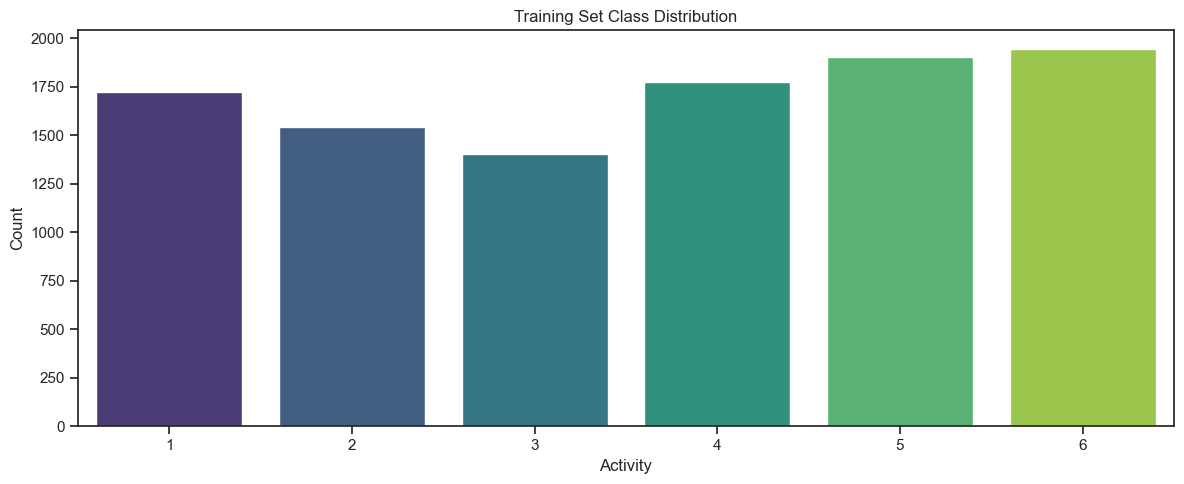

In [9]:
# Class distribution of the dataset
print("Training set class distribution:")
print(data_y[0].value_counts().sort_index())

plt.figure(figsize=(12, 5))

sns.countplot(x=data_y[0], palette='viridis')
plt.title('Training Set Class Distribution')
plt.xlabel('Activity')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [10]:
print("Shape of X_combined:", df.shape)
print("Shape of y_combined:", data_y.shape)
print("Shape of subjects_combined:", data_Subject.shape)

Shape of X_combined: (10299, 1152)
Shape of y_combined: (10299, 1)
Shape of subjects_combined: (10299, 1)


In [11]:
train_indices = data_Subject[data_Subject[0].isin(train_subjects)].index
X_train_final = df.loc[train_indices].reset_index(drop=True)
y_train_final = data_y.loc[train_indices].reset_index(drop=True)

validation_indices = data_Subject[data_Subject[0].isin(validation_subjects)].index
X_val_final = df.loc[validation_indices].reset_index(drop=True)
y_val_final = data_y.loc[validation_indices].reset_index(drop=True)

test_indices = data_Subject[data_Subject[0].isin(test_subjects)].index
X_test_final = df.loc[test_indices].reset_index(drop=True)
y_test_final = data_y.loc[test_indices].reset_index(drop=True)

# Make labels 0-indexed
y_train_final = y_train_final - 1
y_val_final = y_val_final - 1
y_test_final = y_test_final - 1

print(f"Shape of X_train_final: {X_train_final.shape}")
print(f"Shape of y_train_final: {y_train_final.shape}")
print(f"Shape of X_val_final: {X_val_final.shape}")
print(f"Shape of y_val_final: {y_val_final.shape}")
print(f"Shape of X_test_final: {X_test_final.shape}")
print(f"Shape of y_test_final: {y_test_final.shape}")

Shape of X_train_final: (6715, 1152)
Shape of y_train_final: (6715, 1)
Shape of X_val_final: (1789, 1152)
Shape of y_val_final: (1789, 1)
Shape of X_test_final: (1795, 1152)
Shape of y_test_final: (1795, 1)


## PreProcessing

In [ ]:
# Standardize the data using min max scaler to scale data from 0 to 1
scaler = MinMaxScaler()
X_train_final_scaled = scaler.fit_transform(X_train_final)
X_val_final_scaled = scaler.transform(X_val_final)
X_test_final_scaled = scaler.transform(X_test_final)